In [1]:
import os                    
import matplotlib           
import matplotlib.pyplot as plt
import numpy as np            
import astropy.io.fits       
import astropy.coordinates   
import fitsio               
import sdss_access          
from astropy.coordinates import SkyCoord
import astropy.units as u

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.size'] = 14

url_root = 'https://data.sdss.org/sas'
local_root = os.getenv('SAS_BASE_DIR')

sdss_path = sdss_access.path.Path(release='dr19', verbose=True)

# Allspec

In [2]:
sdss_path = sdss_access.path.Path(release='dr19', verbose=True)
access = sdss_access.Access(release='dr19', verbose=True)

allspec_file = sdss_path.full('allspec', vers='1.0.1', release='dr19')

if not sdss_path.exists('', full=allspec_file):
    access.remote()
    access.add('allspec', vers='1.0.1', release='dr19')
    access.set_stream()
    access.commit()

allspec_hdus = astropy.io.fits.open(allspec_file)
allspec = np.array(allspec_hdus[1].data)

In [3]:
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

isfinite = np.isfinite(unique_ra) & np.isfinite(unique_dec)
unique_indx = unique_indx[isfinite]
unique_ra = unique_ra[isfinite]
unique_dec = unique_dec[isfinite]
unique_coords = astropy.coordinates.SkyCoord(unique_ra, unique_dec, unit='deg', frame='icrs')

In [4]:
# SDSS ra and dec of Frie's and Jason's Quasar
EVQs = [(212.67189, 53.313609, 280),(213.351149549, 53.090819798, 175)]
#ra, dec, epoch #

In [5]:
tolerance = 0.005
target_ras = [] 
target_decs = []

for ra, dec, n in EVQs:
    target_ras.append(ra)
    target_decs.append(dec)
    
target_coords = SkyCoord(
    target_ras,
    target_decs,
    unit='deg'
)
# Extract unique objects from allspec (all lowercase here)
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

mask = np.isfinite(unique_ra) & np.isfinite(unique_dec) #np.isfinite from APPM2360 project 2
# np.isfinite https://medium.com/@whyamit404/understanding-numpy-isfinite-with-examples-7305ff609ce9 

# update unique_ra and unique_dec with only usable numbers
unique_ra = unique_ra[mask]
unique_dec = unique_dec[mask]
unique_sdss_id = unique_sdss_id[mask]
unique_coords = SkyCoord(unique_ra, unique_dec, unit='deg') # this is where units='deg' comes in
indx, sep, _ = target_coords.match_to_catalog_sky(unique_coords)
EVQ_sdss_ids = []

for i in range(len(indx)):
    EVQ_sdss_ids.append(unique_sdss_id[indx[i]])
    print(EVQ_sdss_ids)
print(sep.to(u.arcsec).value)


[62243506]
[62243506, 62239511]
[0.23233907 0.07615622]


In [6]:
url_root = 'https://data.sdss.org/sas'
local_root = os.getenv('SAS_BASE_DIR')

In [7]:
EVQs_rows = []
download_files = []
EVQ_ids= []
for sdss_id in EVQ_sdss_ids:
    rows = allspec[allspec['sdss_id'] == sdss_id]
    EVQs_rows.append(rows)
    print(sdss_id, "Number of epochs:", len(rows))

62243506 Number of epochs: 280
62239511 Number of epochs: 175


In [8]:
EVQs_spec= []
download_files= []
for obj_rows in EVQs_rows:
    for row in obj_rows:
        
        sas_url = row['sas_url'].decode()
        local_path = sas_url.replace(url_root, local_root)
        EVQs_spec.append((local_path, row["mjd"], row["sdss_id"]))

        if not os.path.exists(local_path):
            download_files.append(sas_url)

In [9]:
if len(download_files) > 0:
    print("fetching files, please stand by")
    access.remote()
    access.set_stream()
    
    for url in download_files:
        access.add(url)

# disable follow_symlinks
    access.commit(follow_symlinks=False)

In [10]:
spectra = []

for path, mjd, sdss_id in EVQs_spec:
    with astropy.io.fits.open(path) as hdul:
    
        if 'COADD' in hdul:
            coadd = hdul['COADD'].data
        else:
            coadd = hdul['SPECTRUM'].data


        wavelength = 10**coadd['loglam']
        flux = coadd['flux']

        spectra.append({
            "wavelength": wavelength,
            "flux": flux,
            "mjd": mjd,
            "sdss_id": sdss_id
})


In [11]:
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('',full=spall_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()
print(spall_file)

spall_columns = [
    'SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS',
    'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG', 'SPEC_FILE',
    'HEALPIX_PATH', 'OBJTYPE'
]
spall = fitsio.read(spall_file, columns=spall_columns)


/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spAll-v6_1_3.fits.gz


In [12]:
EVQ_z = []

for evq_id in EVQ_sdss_ids:
    
    mask  = spall['SDSS_ID']== evq_id
    z_val = spall['Z'][mask]
    EVQ_z.append(np.nanmedian(z_val))
    

In [13]:
EVQ_z

[0.36196038, 0.4562723]

In [14]:
rest_lambda = {
    "OVI":     1034.0,
    "Lyalpha": 1216.0,
    "CIV":     1549.0,
    "CIII":    1908.0,
    "MGII":    2799.0,
    "Hbeta":   4862.0,
    "Hgamma":  4361.0,
    "Halpha":  6564.0,
    "Oiii": 4959.0
    
}
# We are doing our analysis with Hbeta and H alpha
lmbd_rst_Hbeta = rest_lambda['Hbeta']
lmbd_rst_Halpha = rest_lambda['Halpha']
lmbd_rst_oiii = rest_lambda['Oiii']
cntr_Hbeta = []
cntr_Halpha = []
cntr_Oiii = []
for z in EVQ_z:
    cntr_hb = lmbd_rst_Hbeta * (1+z)
    cntr_Hbeta.append(cntr_hb)
    cntr_ha = lmbd_rst_Halpha * (1+z)
    cntr_Halpha.append(cntr_ha)
    cntr_oiii = lmbd_rst_oiii * (1+z)
    cntr_Oiii.append(cntr_oiii)

    print(f'Hβ observed center: {cntr_hb:.2f} Å')
    print(f'Hα observed center: {cntr_ha:.2f} Å')
    print(f'Oiii observed center: {cntr_oiii:.2f} Å')
    

Hβ observed center: 6621.85 Å
Hα observed center: 8939.91 Å
Oiii observed center: 6753.96 Å
Hβ observed center: 7080.40 Å
Hα observed center: 9558.97 Å
Oiii observed center: 7221.65 Å


In [15]:
center_map = dict(zip(EVQ_sdss_ids, zip(cntr_Hbeta, cntr_Halpha,cntr_Oiii )))
for sdss_id, (cntrHb, cntrHa, cntrOiii) in center_map.items():
    print(sdss_id, cntrHb, cntrHa, cntrOiii)

62243506 6621.85137373209 8939.907942652702 6753.961530715227
62239511 7080.39594233036 9558.971403837204 7221.654355823994


In [16]:
import matplotlib.cm as cm

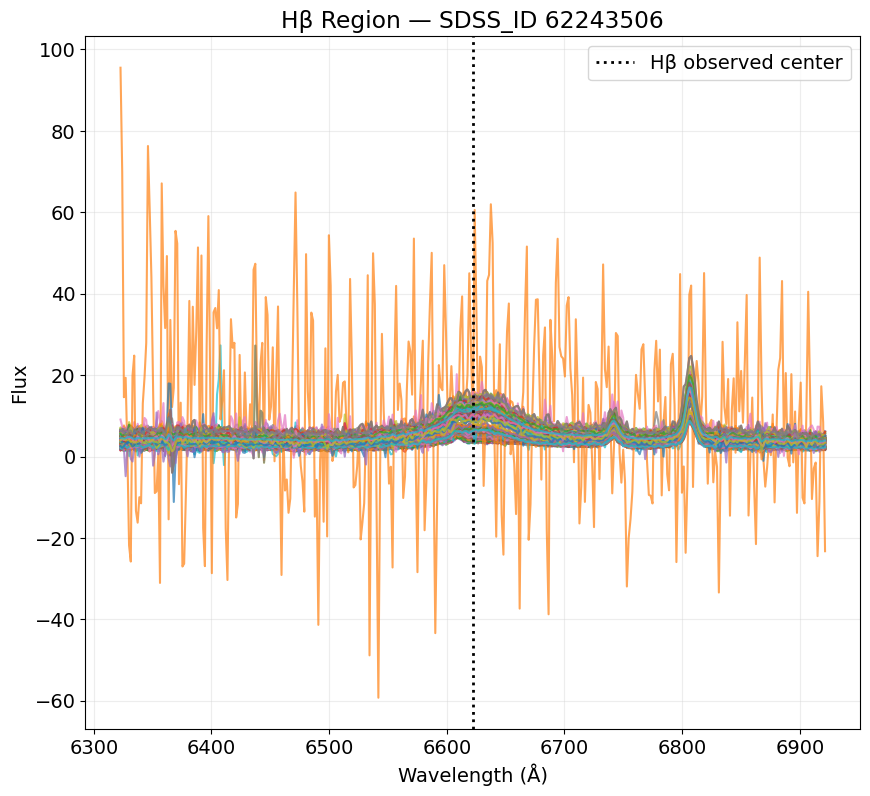

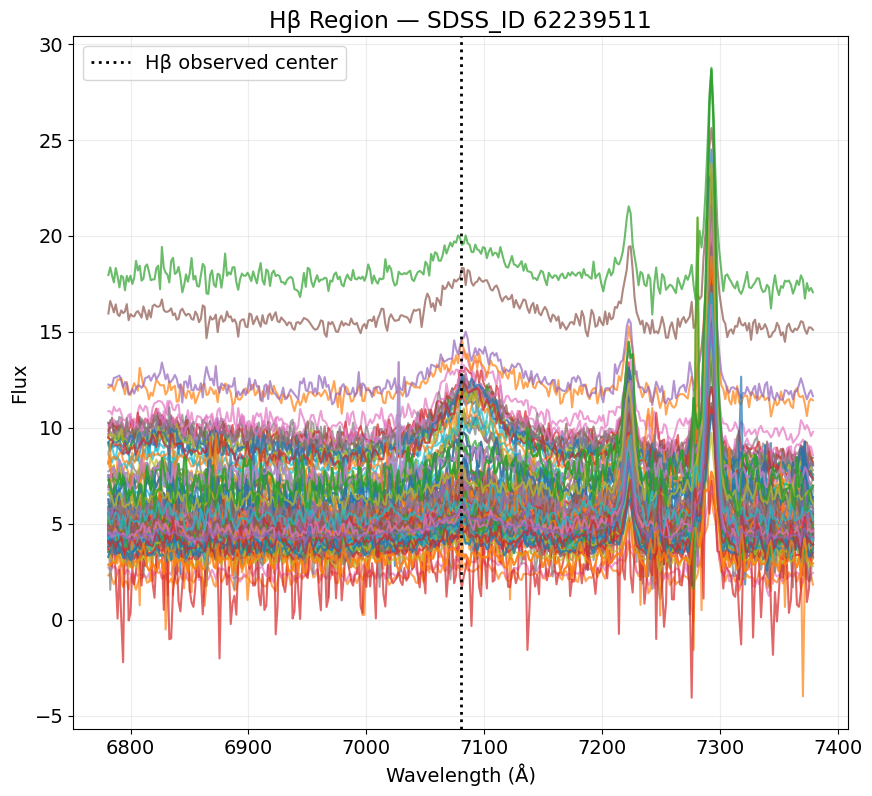

In [27]:
colors = [
    "#1f77b4",  # blue
    "#d62728",  # red
    "#2ca02c",  # green
    "#ff7f0e",  # orange
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf"   # cyan
]

plt.rcParams['text.usetex'] = False
plt.rcParams['figure.figsize'] = [15,10]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

max_flux_Hb = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]
    max_flux_Hb[target_id] = []
    plt.figure(figsize=(10,9))

    matching_spectra = [s for s in spectra if s["sdss_id"] == target_id]

    for i, s in enumerate(matching_spectra):
        wl = s["wavelength"]
        fl = s["flux"]

        mask_beta = (wl > cntrHb - 300) & (wl < cntrHb + 300)

        if not np.any(mask_beta):
            continue

        wl_beta = wl[mask_beta]
        fl_beta = fl[mask_beta]

        if len(fl_beta) == 0:
            continue

        max_flux = np.max(fl_beta)

        if max_flux == 0 or not np.isfinite(max_flux):
            continue

        max_flux_Hb[target_id].append(max_flux)
        peak_idx = np.argmax(fl_beta)
        peak_wl = wl_beta[peak_idx]

        plt.plot(wl_beta, fl_beta, color=colors[i % len(colors)], alpha=0.7)

    plt.axvline(x=cntrHb, color="black", linestyle=":", linewidth=2, label="Hβ observed center")

    plt.xlabel("Wavelength (Å)", color="black")
    plt.ylabel("Flux", color="black")
    plt.title(f"Hβ Region — SDSS_ID {target_id}", color="black")
    plt.tick_params(axis='both', labelcolor="black")
    plt.grid(True, which='both', color="lightgray", alpha=0.4)

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    plt.show()

In [21]:
def continuum_flux(wl, fl, center, width=40):
    lam_min = center - width
    lam_max = center + width
    mask = (wl > lam_min) & (wl < lam_max)
    return np.nanmedian(fl[mask])



In [22]:
def line_flux(wl, fl, center, width=40):
    lam_min = center - width
    lam_max = center + width

    mask = (wl > lam_min) & (wl < lam_max)

    # continuum from edges
    cont_mask = ((wl > lam_min) & (wl < lam_min+10)) | \
                ((wl < lam_max) & (wl > lam_max-10))
    cont = np.nanmedian(fl[cont_mask])

    return np.trapz(fl[mask] - cont, wl[mask])

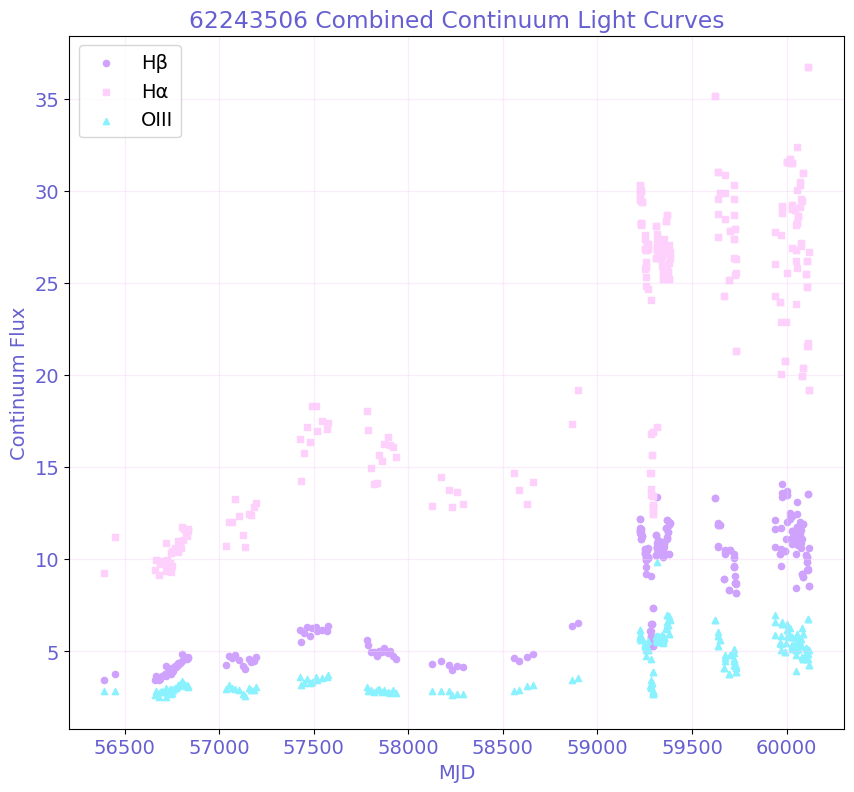

[WARNING]: Mean of empty slice (RuntimeWarning)


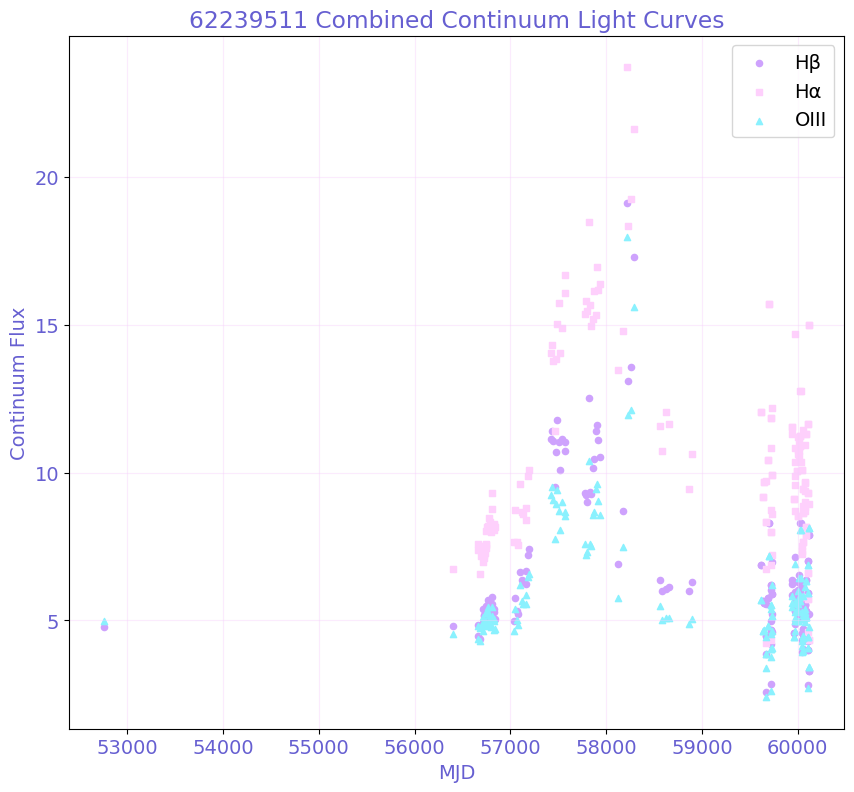

In [23]:
times_hb = {}
cont_hb = {}

times_ha = {}
cont_ha= {}

times_oiii = {}
cont_oiii = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntr_Oiii  = center_map[target_id]
    times_hb[target_id] = []
    cont_hb[target_id] = []
    
    cont_ha[target_id] = []
    times_ha[target_id] = []
    
    times_oiii[target_id] = []
    cont_oiii[target_id] = []
    plt.figure(figsize=(10,9))
    for s in spectra:
        if s["sdss_id"] == target_id:
            wl = s["wavelength"]
            fl = s["flux"]
            mjd = s["mjd"]
            f_cont = continuum_flux(wl, fl, cntrHb, width=40)
            times_hb[target_id].append(mjd)
            cont_hb[target_id].append(f_cont)
            f_cont = continuum_flux(wl, fl, cntrHa, width=40)
            times_ha[target_id].append(mjd)
            cont_ha[target_id].append(f_cont)
            f_cont = continuum_flux(wl, fl, cntr_Oiii, width=40)
            times_oiii[target_id].append(mjd)
            cont_oiii[target_id].append(f_cont)

    plt.scatter(times_hb[target_id], cont_hb[target_id], color="xkcd:lilac",label="Hβ",  s=20,marker='o')
    plt.scatter(times_ha[target_id], cont_ha[target_id], color="xkcd:pale mauve",label="Hα",  s=20,marker='s')
    plt.scatter(times_oiii[target_id], cont_oiii[target_id], color= "xkcd:robin egg blue", label="OIII", s=20,marker='^')
    plt.ylabel("Continuum Flux",color="xkcd:dark periwinkle")
    plt.xlabel("MJD",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.4)
    plt.title(f"{target_id} Combined Continuum Light Curves",color="xkcd:dark periwinkle")
    plt.legend()
    plt.show();



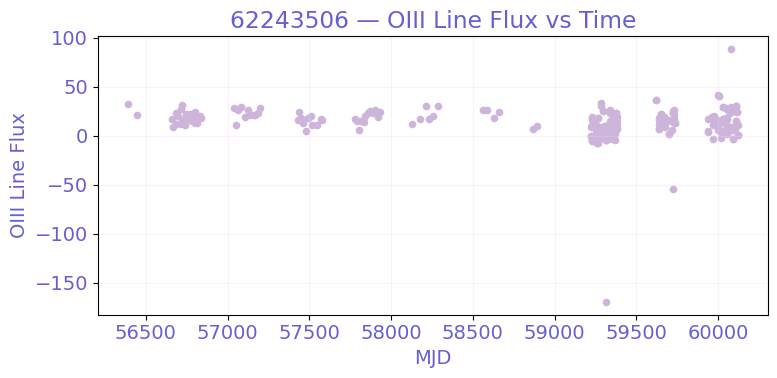

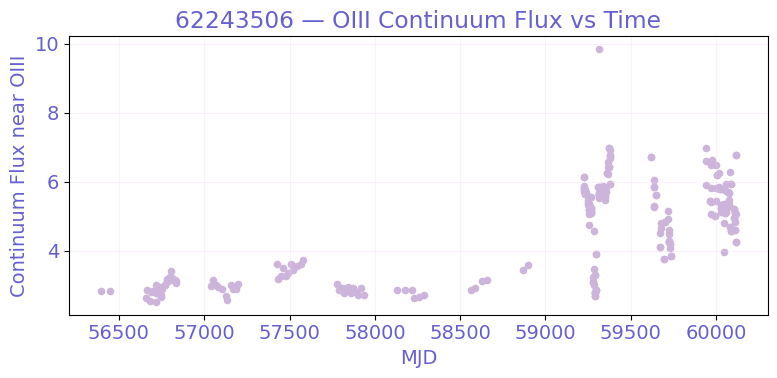

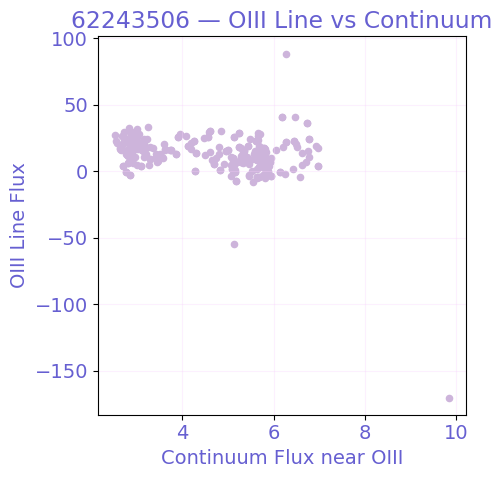

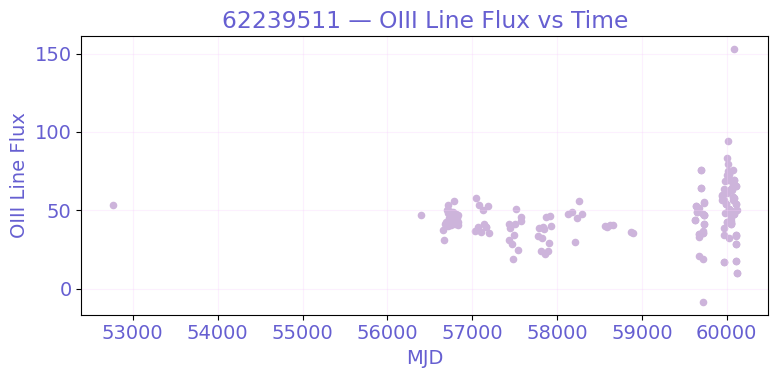

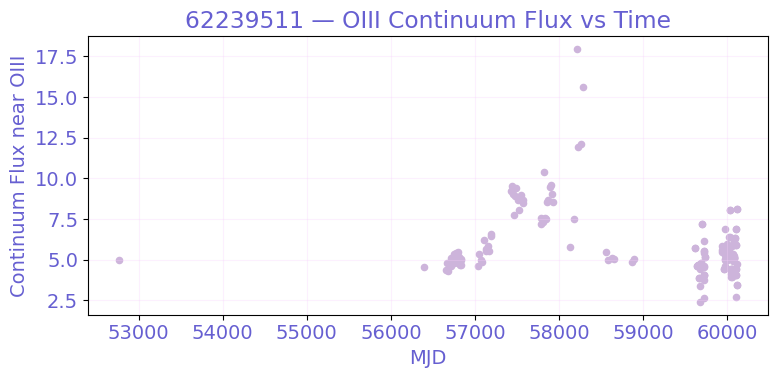

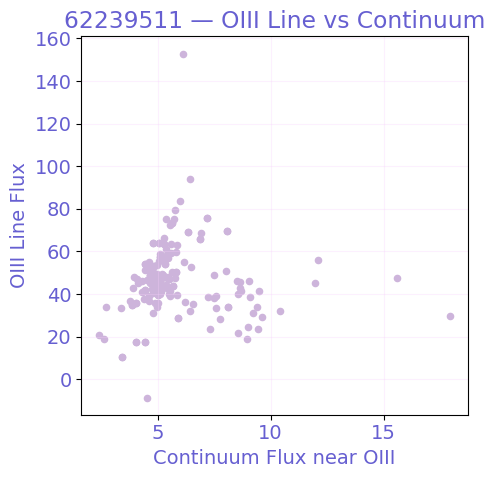

In [24]:
oiii_times = {}
oiii_flux = {}
cont_oiii = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    oiii_times[target_id] = []
    oiii_flux[target_id] = []
    cont_oiii[target_id] = []

    for s in spectra:
        if s["sdss_id"] == target_id:
            wl = s["wavelength"]
            fl = s["flux"]
            mjd = s["mjd"]

            # same style as Fries
            f_line = line_flux(wl, fl, cntrOiii, width=40)
            f_cont = continuum_flux(wl, fl, cntrOiii, width=40)

            if not np.isfinite(f_line) or not np.isfinite(f_cont):
                continue

            oiii_times[target_id].append(mjd)
            oiii_flux[target_id].append(f_line)
            cont_oiii[target_id].append(f_cont)

    # sort by time
    if len(oiii_times[target_id]) > 0:
        order = np.argsort(oiii_times[target_id])
        oiii_times[target_id] = np.array(oiii_times[target_id])[order]
        oiii_flux[target_id] = np.array(oiii_flux[target_id])[order]
        cont_oiii[target_id] = np.array(cont_oiii[target_id])[order]

    # OIII line flux vs time
    plt.figure(figsize=(8,4))
    plt.scatter(oiii_times[target_id], oiii_flux[target_id], s=20)
    plt.xlabel("MJD",color="xkcd:dark periwinkle")
    plt.ylabel("OIII Line Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — OIII Line Flux vs Time",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    plt.tight_layout()
    plt.show()

    # OIII continuum vs time
    plt.figure(figsize=(8,4))
    plt.scatter(oiii_times[target_id], cont_oiii[target_id], s=20)
    plt.xlabel("MJD",color="xkcd:dark periwinkle")
    plt.ylabel("Continuum Flux near OIII",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — OIII Continuum Flux vs Time",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    plt.tight_layout()
    plt.show()

    # line flux vs continuum
    plt.figure(figsize=(5,5))
    plt.scatter(cont_oiii[target_id], oiii_flux[target_id], s=20)
    plt.xlabel("Continuum Flux near OIII",color="xkcd:dark periwinkle")
    plt.ylabel("OIII Line Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — OIII Line vs Continuum",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    plt.tight_layout()
    plt.show()

## ******* SUPER IMPORTANT FOR OUTLINE INTERPRETATIONS:*******OIII************************************************

##    If the continuum varies a lot but the Oiii line flux is flat this is good and is consistent w/ Oiii being invariable (a good narrow-line calibrator)
##    ALSO If line flux and continuum are loosly correlated this is GOOD (for OIII note Hbeta) becasue that suggests that Oiii originated in the vast, slowly varying NLR and supports our use of it as a flux calibrator reference (like in Lab03).
##    This is why Jason didn't explain how to just get rid of the crazy red line. I suspect we are supposed to diagnose which epochs have low S/N or are badly calibrated epochs, outliers, etc. in order to justify getting rid of them scientificaly not just for visual appeal.


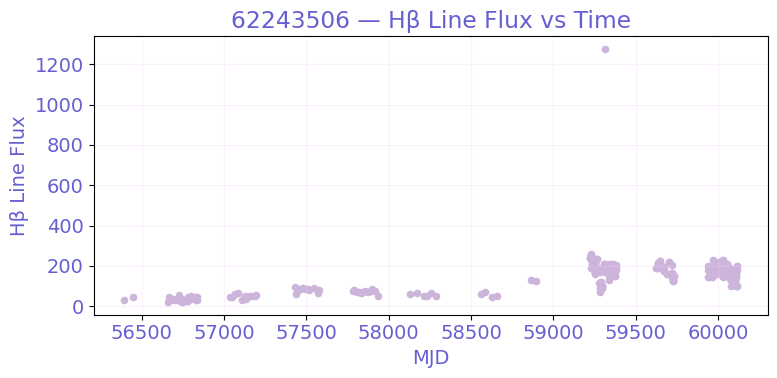

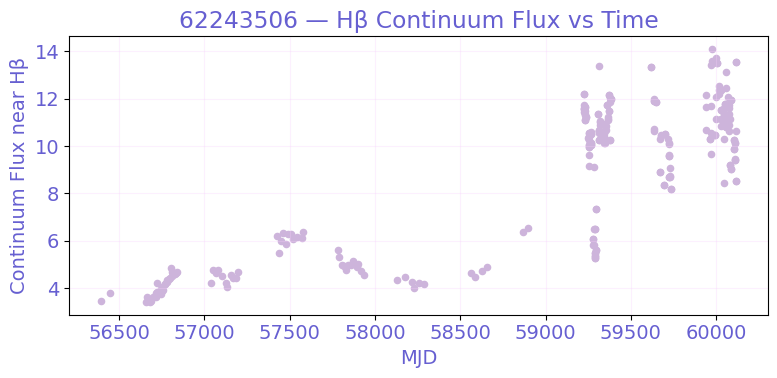

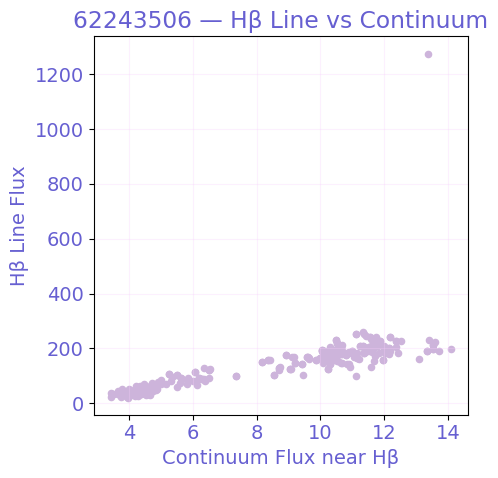

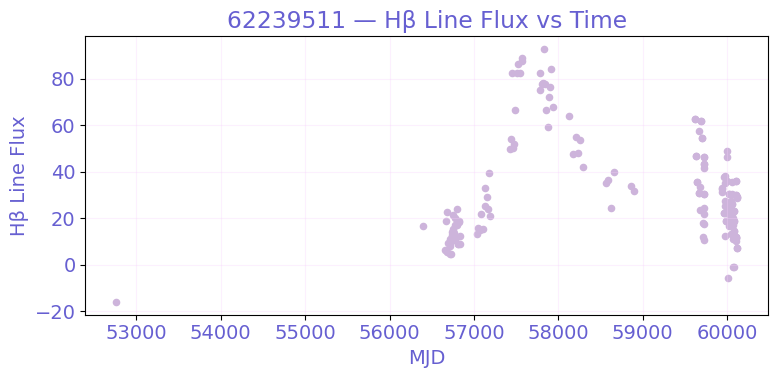

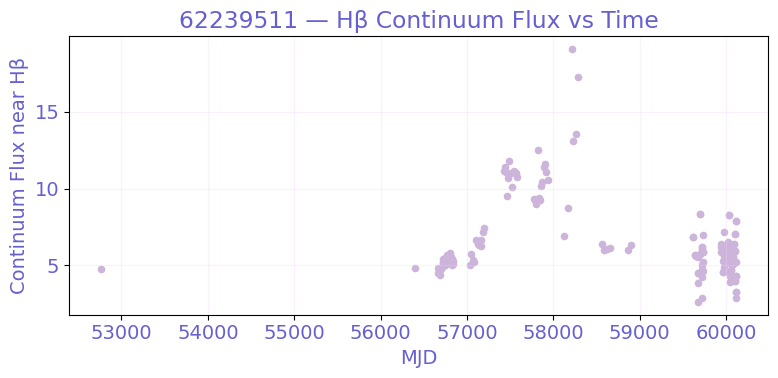

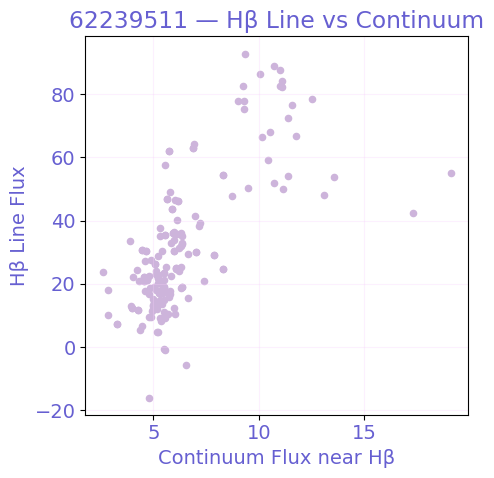

In [26]:
Hb_times = {}
Hb_flux = {}
cont_Hb = {}

hb_center_map = {
    62243506: 6621.85,
    62239511: 7080.40
}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    Hb_times[target_id] = []
    Hb_flux[target_id] = []
    cont_Hb[target_id] = []

    hb_center = hb_center_map[target_id]

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl  = s["wavelength"]
        fl  = s["flux"]
        mjd = s["mjd"]

        f_line = line_flux(wl, fl, hb_center, width=40)
        f_cont = continuum_flux(wl, fl, hb_center, width=40)

        if not np.isfinite(f_line) or not np.isfinite(f_cont):
            continue

        Hb_times[target_id].append(mjd)
        Hb_flux[target_id].append(f_line)
        cont_Hb[target_id].append(f_cont)

    if len(Hb_times[target_id]) > 0:
        order = np.argsort(Hb_times[target_id])
        Hb_times[target_id] = np.array(Hb_times[target_id])[order]
        Hb_flux[target_id] = np.array(Hb_flux[target_id])[order]
        cont_Hb[target_id] = np.array(cont_Hb[target_id])[order]

    plt.figure(figsize=(8,4))
    plt.scatter(Hb_times[target_id], Hb_flux[target_id], s=20)
    plt.xlabel("MJD", color="xkcd:dark periwinkle")
    plt.ylabel("Hβ Line Flux", color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — Hβ Line Flux vs Time", color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.scatter(Hb_times[target_id], cont_Hb[target_id], s=20)
    plt.xlabel("MJD", color="xkcd:dark periwinkle")
    plt.ylabel("Continuum Flux near Hβ", color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — Hβ Continuum Flux vs Time", color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,5))
    plt.scatter(cont_Hb[target_id], Hb_flux[target_id], s=20)
    plt.xlabel("Continuum Flux near Hβ", color="xkcd:dark periwinkle")
    plt.ylabel("Hβ Line Flux", color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — Hβ Line vs Continuum", color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha=0.3)
    plt.tight_layout()
    plt.show()

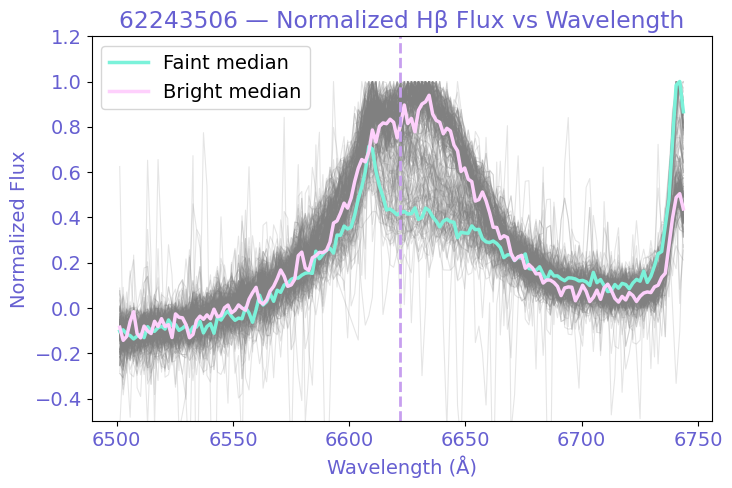

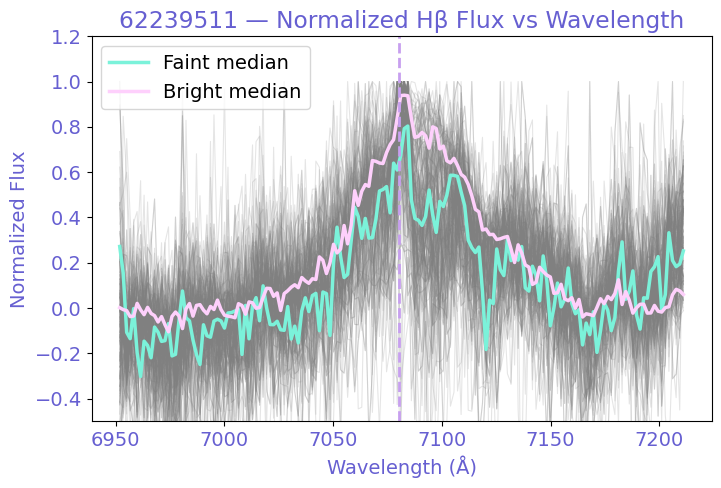

In [27]:
# Parameters
window = 80   # around Hbeta
edge   = 20   # continuum estimate from edges

hb_profiles   = {}
hb_wavelength = {}
cont_levels   = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    hb_profiles[target_id] = []
    hb_wavelength[target_id] = []
    cont_levels[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl = s["wavelength"]
        fl = s["flux"]

        # center index around Hβ
        i = np.argmin(np.abs(wl - cntrHb))

        # skip if window runs off array
        if i - window < 0 or i + window > len(wl):
            continue

        wl_zoom = wl[i-window:i+window]
        fl_zoom = fl[i-window:i+window]

        # continuum estimate from edges
        cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
        cont = np.median(cont_vals)

        # continuum-subtracted line
        fl_line = fl_zoom - cont

        # peak normalization
        peak = np.max(fl_line)
        if peak <= 0 or not np.isfinite(peak):
            continue

        fl_norm = fl_line / peak

        hb_profiles[target_id].append(fl_norm)
        hb_wavelength[target_id].append(wl_zoom)
        cont_levels[target_id].append(cont)

    # convert only this target's lists
    hb_profiles[target_id] = np.array(hb_profiles[target_id])
    hb_wavelength[target_id] = np.array(hb_wavelength[target_id])
    cont_levels[target_id] = np.array(cont_levels[target_id])

    # skip empty target
    if len(cont_levels[target_id]) == 0:
        continue

    # Bright and faint medians
    order = np.argsort(cont_levels[target_id])
    n_select = min(10, len(order))

    faint_idx = order[:n_select]
    bright_idx = order[-n_select:]

    wl_ref = hb_wavelength[target_id][0]
    bright_med = np.median(hb_profiles[target_id][bright_idx], axis=0)
    faint_med  = np.median(hb_profiles[target_id][faint_idx], axis=0)

    plt.figure(figsize=(8,5))

    # all epochs in gray
    for wl_zoom, prof in zip(hb_wavelength[target_id], hb_profiles[target_id]):
        plt.plot(wl_zoom, prof, color="gray", alpha=0.2, linewidth=0.8)

    # medians
    plt.plot(wl_ref, faint_med, color="xkcd:tiffany blue", linewidth=2.5, label="Faint median")
    plt.plot(wl_ref, bright_med, color="xkcd:pale mauve" , linewidth=2.5, label="Bright median")

    plt.axvline(cntrHb, color="xkcd:lavender", linestyle="--", linewidth=2)

    plt.xlabel("Wavelength (Å)",color="xkcd:dark periwinkle")
    plt.ylabel("Normalized Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — Normalized Hβ Flux vs Wavelength",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    #plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    plt.ylim(-0.5, 1.2)
    plt.legend()
    plt.show()

## ****************"(Fries) Normalized Hβ Flux vs Wavelength" interpretation**************************

##    The Dotted line is at ~ 6621.85 Ang. It shows the observed frame center for the h beta emission line. Similar to lab03 this gives us an idea of where we would expect a peak value from the calculated z
##    I used np.argsort() to sort the epochs by their continuum brightness then took the 10 faintest and 10 brightest to compute their medians. Medians usually get rid of the noise and outliers best.
##    This plot is intriguing because it shows that the brighter median (the pink one) is broader and peaks higher at H beta, as expected. These techniques are used in reverberation mapping a lot.


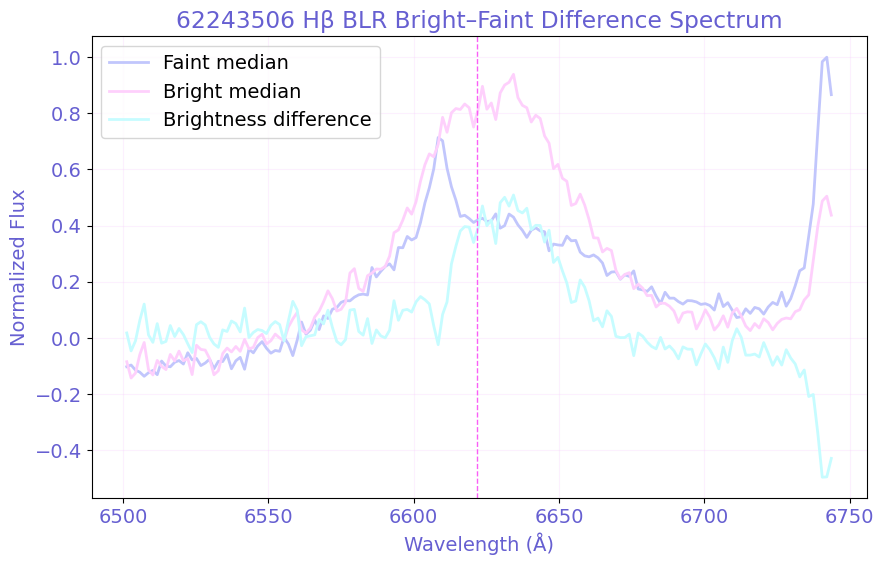

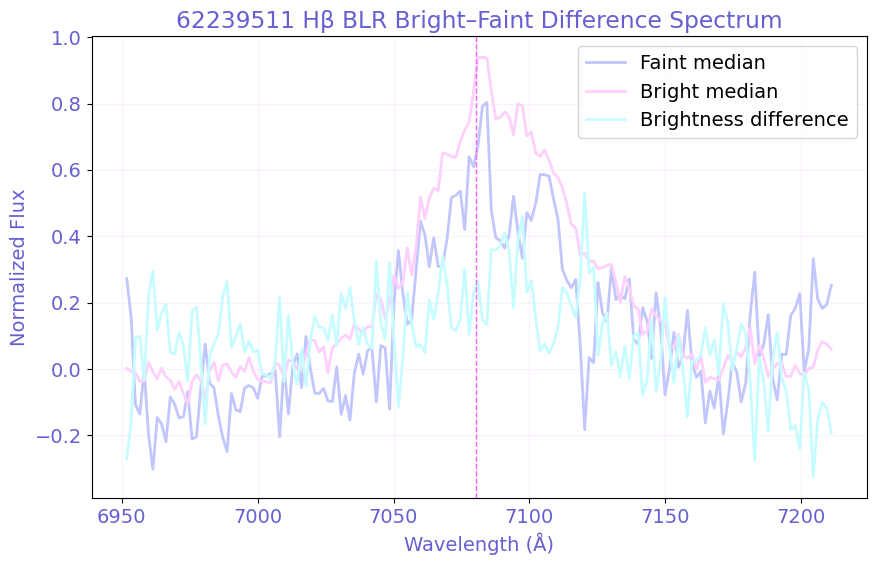

In [28]:
window = 80
edge = 20

hb_profiles = {}
hb_wavelength = {}
cont_levels = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    hb_profiles[target_id] = []
    hb_wavelength[target_id] = []
    cont_levels[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl = s["wavelength"]
        fl = s["flux"]

        # center index around Hβ
        i = np.argmin(np.abs(wl - cntrHb))

        # skip if window runs off array
        if i - window < 0 or i + window > len(wl):
            continue

        wl_zoom = wl[i-window:i+window]
        fl_zoom = fl[i-window:i+window]

        # continuum estimate from edges
        cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
        cont = np.median(cont_vals)

        # continuum-subtracted line
        fl_line = fl_zoom - cont

        # peak normalization
        peak = np.max(fl_line)
        if peak <= 0 or not np.isfinite(peak):
            continue

        fl_norm = fl_line / peak

        hb_profiles[target_id].append(fl_norm)
        hb_wavelength[target_id].append(wl_zoom)
        cont_levels[target_id].append(cont)

    hb_profiles[target_id] = np.array(hb_profiles[target_id])
    hb_wavelength[target_id] = np.array(hb_wavelength[target_id])
    cont_levels[target_id] = np.array(cont_levels[target_id])

    if len(cont_levels[target_id]) == 0:
        continue

    order = np.argsort(cont_levels[target_id])
    n_select = min(10, len(order))

    faint_idx = order[:n_select]
    bright_idx = order[-n_select:]

    wl_ref = hb_wavelength[target_id][0]
    faint_med = np.median(hb_profiles[target_id][faint_idx], axis=0)
    bright_med = np.median(hb_profiles[target_id][bright_idx], axis=0)

    diff = bright_med - faint_med

    plt.figure(figsize=(10,6))
    plt.plot(wl_ref, faint_med, color="xkcd:light periwinkle", linewidth=2, label="Faint median")
    plt.plot(wl_ref, bright_med, color="xkcd:pale mauve", linewidth=2, label="Bright median")
    plt.plot(wl_ref, diff, color="xkcd:light sky blue", linewidth=2, label="Brightness difference")

    plt.axvline(cntrHb, color="xkcd:light magenta", linestyle="--", linewidth=1)

    plt.xlabel("Wavelength (Å)",color="xkcd:dark periwinkle")
    plt.ylabel("Normalized Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} Hβ BLR Bright–Faint Difference Spectrum",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    plt.legend()
    plt.show()

## ****************************(Fries) Hβ BLR Bright Faint Difference Spectrum*************************

##    This pink line should give us a better idea of where the BLR varies the most


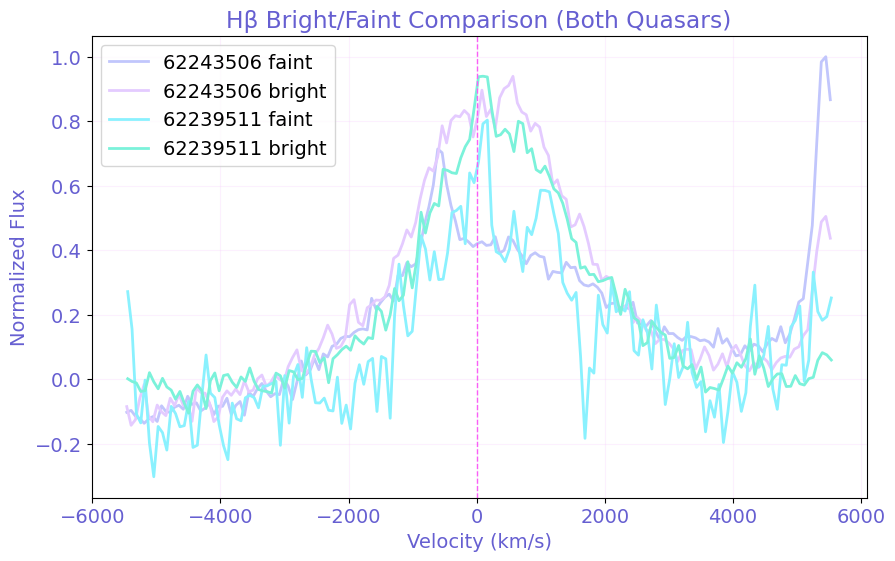

In [29]:
c = 3e5
window = 80
edge = 20
n_select = 10

hb_profiles = {}
hb_vel = {}
cont_levels = {}

faint_med_all = {}
bright_med_all = {}
vel_ref_all = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    hb_profiles[target_id] = []
    hb_vel[target_id] = []
    cont_levels[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl = s["wavelength"]
        fl = s["flux"]

        i = np.argmin(np.abs(wl - cntrHb))

        if i - window < 0 or i + window > len(wl):
            continue

        wl_zoom = wl[i-window:i+window]
        fl_zoom = fl[i-window:i+window]

        cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
        cont = np.median(cont_vals)

        fl_line = fl_zoom - cont

        peak = np.max(fl_line)
        if peak <= 0 or not np.isfinite(peak):
            continue

        fl_norm = fl_line / peak
        vel = c * (wl_zoom - cntrHb) / cntrHb

        hb_profiles[target_id].append(fl_norm)
        hb_vel[target_id].append(vel)
        cont_levels[target_id].append(cont)

    hb_profiles[target_id] = np.array(hb_profiles[target_id])
    hb_vel[target_id] = np.array(hb_vel[target_id])
    cont_levels[target_id] = np.array(cont_levels[target_id])

    if len(cont_levels[target_id]) == 0:
        continue

    order = np.argsort(cont_levels[target_id])
    n_use = min(n_select, len(order))

    faint_idx = order[:n_use]
    bright_idx = order[-n_use:]

    vel_ref_all[target_id] = hb_vel[target_id][0]
    faint_med_all[target_id] = np.median(hb_profiles[target_id][faint_idx], axis=0)
    bright_med_all[target_id] = np.median(hb_profiles[target_id][bright_idx], axis=0)

# ---------- PLOT BOTH TOGETHER ----------
plt.figure(figsize=(10,6))

# first quasar
plt.plot(vel_ref_all[62243506], faint_med_all[62243506],
         color="xkcd:light periwinkle", linewidth=2, label="62243506 faint")
plt.plot(vel_ref_all[62243506], bright_med_all[62243506],
         color="xkcd:pale lilac", linewidth=2, label="62243506 bright")

# second quasar
plt.plot(vel_ref_all[62239511], faint_med_all[62239511],
         color="xkcd:robin egg blue", linewidth=2, label="62239511 faint")
plt.plot(vel_ref_all[62239511], bright_med_all[62239511],
         color="xkcd:tiffany blue", linewidth=2, label="62239511 bright")

plt.axvline(0, color="xkcd:light magenta", linestyle="--", linewidth=1)

plt.xlabel("Velocity (km/s)",color="xkcd:dark periwinkle")
plt.ylabel("Normalized Flux",color="xkcd:dark periwinkle")
plt.title("Hβ Bright/Faint Comparison (Both Quasars)",color="xkcd:dark periwinkle")
plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
plt.legend()
plt.show()

# H$\alpha$

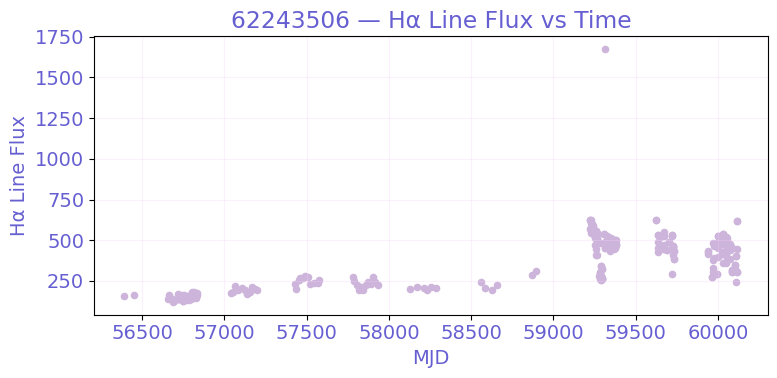

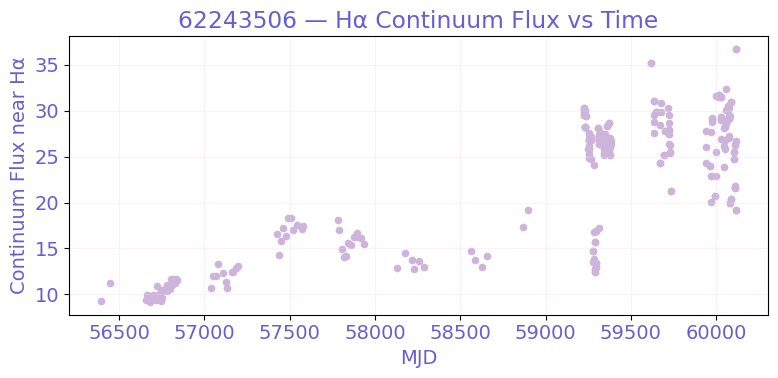

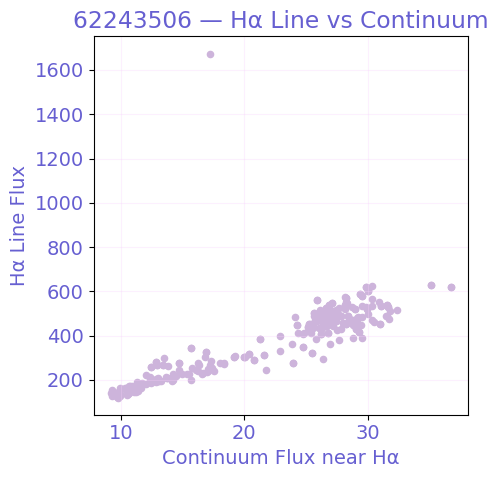

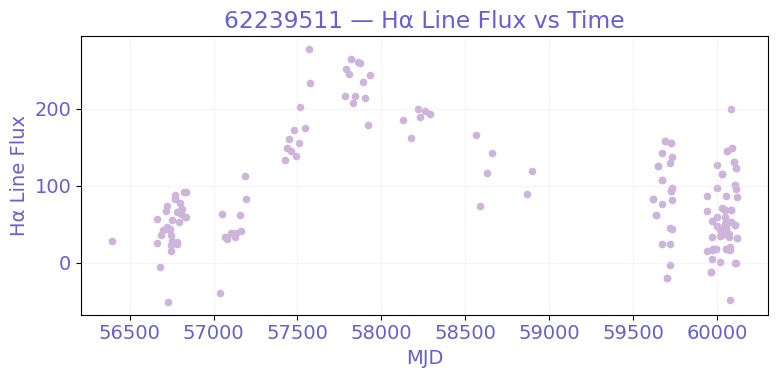

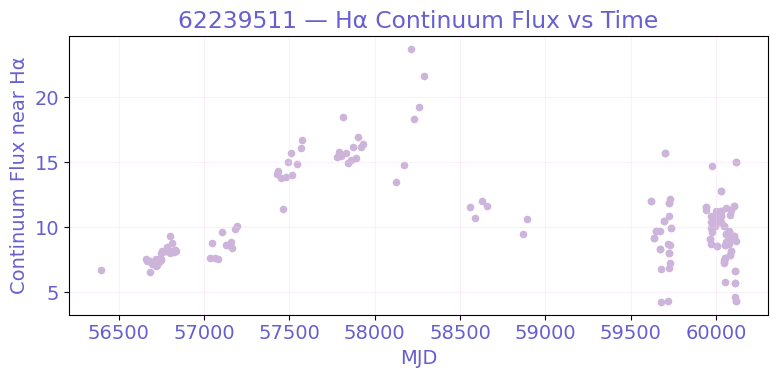

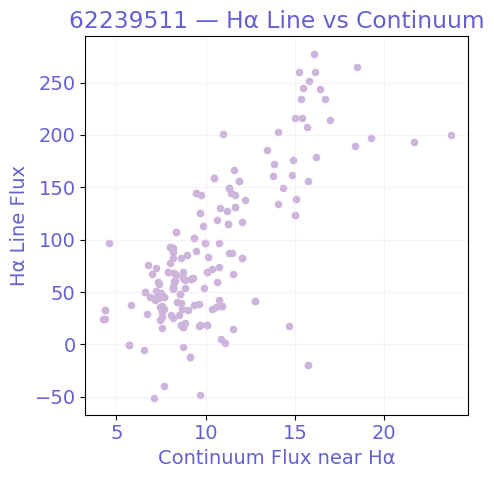

In [30]:
Ha_times = {}
Ha_flux = {}
cont_Ha = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    Ha_times[target_id] = []
    Ha_flux[target_id] = []
    cont_Ha[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl  = s["wavelength"]
        fl  = s["flux"]
        mjd = s["mjd"]

        f_line = line_flux(wl, fl, cntrHa, width=40)
        f_cont = continuum_flux(wl, fl, cntrHa, width=40)

        if not np.isfinite(f_line) or not np.isfinite(f_cont):
            continue

        Ha_times[target_id].append(mjd)
        Ha_flux[target_id].append(f_line)
        cont_Ha[target_id].append(f_cont)

    if len(Ha_times[target_id]) > 0:
        order = np.argsort(Ha_times[target_id])
        Ha_times[target_id] = np.array(Ha_times[target_id])[order]
        Ha_flux[target_id] = np.array(Ha_flux[target_id])[order]
        cont_Ha[target_id] = np.array(cont_Ha[target_id])[order]

    plt.figure(figsize=(8,4))
    plt.scatter(Ha_times[target_id], Ha_flux[target_id], s=20)
    plt.xlabel("MJD",color="xkcd:dark periwinkle")
    plt.ylabel("Hα Line Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — Hα Line Flux vs Time",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.scatter(Ha_times[target_id], cont_Ha[target_id], s=20)
    plt.xlabel("MJD",color="xkcd:dark periwinkle")
    plt.ylabel("Continuum Flux near Hα",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — Hα Continuum Flux vs Time",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,5))
    plt.scatter(cont_Ha[target_id], Ha_flux[target_id], s=20)
    plt.xlabel("Continuum Flux near Hα",color="xkcd:dark periwinkle")
    plt.ylabel("Hα Line Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — Hα Line vs Continuum",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    plt.tight_layout()
    plt.show()
    

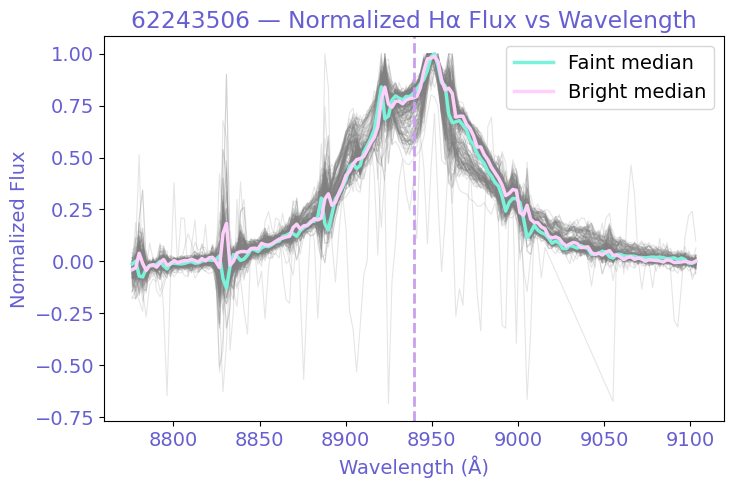

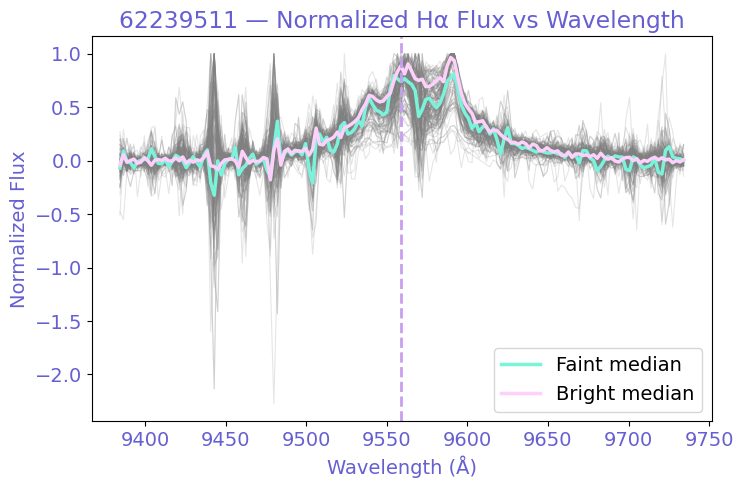

In [186]:
# Parameters
window = 80   # around Halpha
edge   = 20   # continuum estimate from edges

ha_profiles   = {}
ha_wavelength = {}
cont_levels   = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    ha_profiles[target_id] = []
    ha_wavelength[target_id] = []
    cont_levels[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl = s["wavelength"]
        fl = s["flux"]

        # center index around Hα
        i = np.argmin(np.abs(wl - cntrHa))

        # skip if window runs off array
        if i - window < 0 or i + window > len(wl):
            continue

        wl_zoom = wl[i-window:i+window]
        fl_zoom = fl[i-window:i+window]

        # continuum estimate from edges
        cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
        cont = np.median(cont_vals)

        # continuum-subtracted line
        fl_line = fl_zoom - cont

        # peak normalization
        peak = np.max(fl_line)
        if peak <= 0 or not np.isfinite(peak):
            continue

        fl_norm = fl_line / peak

        ha_profiles[target_id].append(fl_norm)
        ha_wavelength[target_id].append(wl_zoom)
        cont_levels[target_id].append(cont)

    ha_profiles[target_id] = np.array(ha_profiles[target_id])
    ha_wavelength[target_id] = np.array(ha_wavelength[target_id])
    cont_levels[target_id] = np.array(cont_levels[target_id])

    if len(cont_levels[target_id]) == 0:
        continue

    order = np.argsort(cont_levels[target_id])
    n_select = min(10, len(order))

    faint_idx = order[:n_select]
    bright_idx = order[-n_select:]

    wl_ref = ha_wavelength[target_id][0]
    bright_med = np.median(ha_profiles[target_id][bright_idx], axis=0)
    faint_med  = np.median(ha_profiles[target_id][faint_idx], axis=0)

    plt.figure(figsize=(8,5))

    # all epochs in gray
    for wl_zoom, prof in zip(ha_wavelength[target_id], ha_profiles[target_id]):
        plt.plot(wl_zoom, prof, color="gray", alpha=0.2, linewidth=0.8)

    # medians
    plt.plot(wl_ref, faint_med, color="xkcd:tiffany blue", linewidth=2.5, label="Faint median")
    plt.plot(wl_ref, bright_med, color="xkcd:pale mauve", linewidth=2.5, label="Bright median")

    plt.axvline(cntrHa, color="xkcd:lavender", linestyle="--", linewidth=2)

    plt.xlabel("Wavelength (Å)",color="xkcd:dark periwinkle")
    plt.ylabel("Normalized Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — Normalized Hα Flux vs Wavelength",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.legend()
    plt.show()

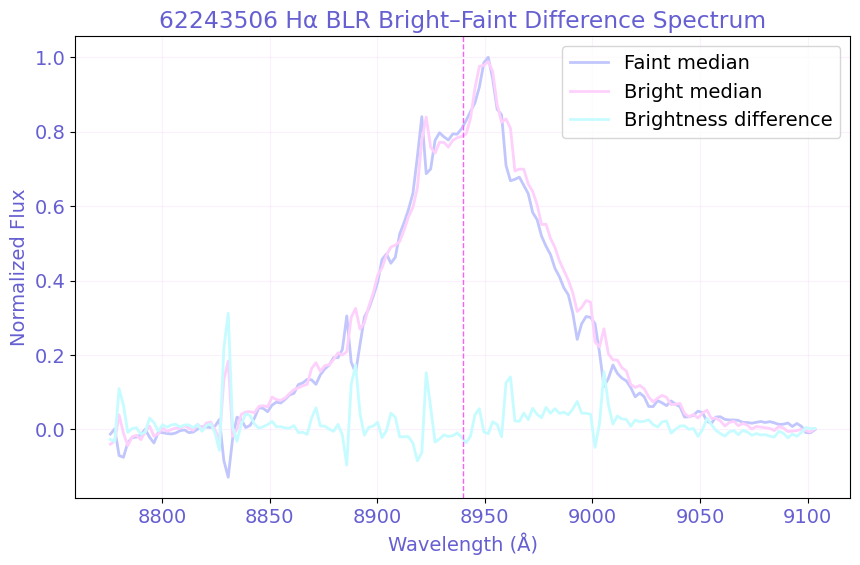

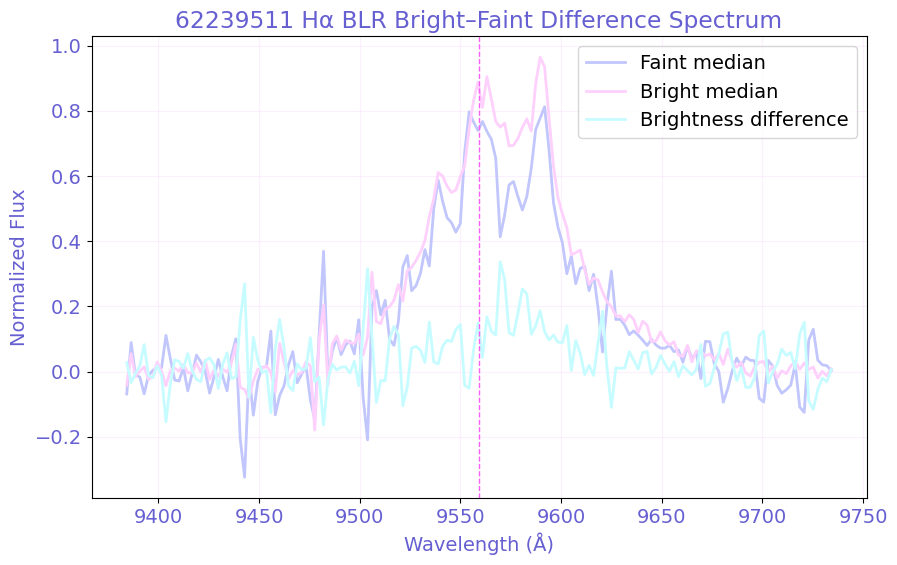

In [190]:
window = 80
edge = 20

hb_profiles = {}
hb_wavelength = {}
cont_levels = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    ha_profiles[target_id] = []
    ha_wavelength[target_id] = []
    cont_levels[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl = s["wavelength"]
        fl = s["flux"]

        # center index around Hβ
        i = np.argmin(np.abs(wl - cntrHa))

        # skip if window runs off array
        if i - window < 0 or i + window > len(wl):
            continue

        wl_zoom = wl[i-window:i+window]
        fl_zoom = fl[i-window:i+window]

        # continuum estimate from edges
        cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
        cont = np.median(cont_vals)

        # continuum-subtracted line
        fl_line = fl_zoom - cont

        # peak normalization
        peak = np.max(fl_line)
        if peak <= 0 or not np.isfinite(peak):
            continue

        fl_norm = fl_line / peak

        ha_profiles[target_id].append(fl_norm)
        ha_wavelength[target_id].append(wl_zoom)
        cont_levels[target_id].append(cont)

    ha_profiles[target_id] = np.array(ha_profiles[target_id])
    ha_wavelength[target_id] = np.array(ha_wavelength[target_id])
    cont_levels[target_id] = np.array(cont_levels[target_id])

    if len(cont_levels[target_id]) == 0:
        continue

    order = np.argsort(cont_levels[target_id])
    n_select = min(10, len(order))

    faint_idx = order[:n_select]
    bright_idx = order[-n_select:]

    wl_ref = ha_wavelength[target_id][0]
    faint_med = np.median(ha_profiles[target_id][faint_idx], axis=0)
    bright_med = np.median(ha_profiles[target_id][bright_idx], axis=0)

    diff = bright_med - faint_med

    plt.figure(figsize=(10,6))
    plt.plot(wl_ref, faint_med, color="xkcd:light periwinkle", linewidth=2, label="Faint median")
    plt.plot(wl_ref, bright_med, color="xkcd:pale mauve", linewidth=2, label="Bright median")
    plt.plot(wl_ref, diff, color="xkcd:light sky blue", linewidth=2, label="Brightness difference")

    plt.axvline(cntrHa, color="xkcd:light magenta", linestyle="--", linewidth=1)

    plt.xlabel("Wavelength (Å)",color="xkcd:dark periwinkle")
    plt.ylabel("Normalized Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} Hα BLR Bright–Faint Difference Spectrum",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    plt.legend()
    plt.show()

In [ ]:
c = 3e5
window = 80
edge = 20
n_select = 10

ha_profiles = {}
ha_vel = {}
cont_levels = {}

faint_med_all = {}
bright_med_all = {}
vel_ref_all = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    ha_profiles[target_id] = []
    ha_vel[target_id] = []
    cont_levels[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl = s["wavelength"]
        fl = s["flux"]

        i = np.argmin(np.abs(wl - cntrHa))

        if i - window < 0 or i + window > len(wl):
            continue

        wl_zoom = wl[i-window:i+window]
        fl_zoom = fl[i-window:i+window]

        cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
        cont = np.median(cont_vals)

        fl_line = fl_zoom - cont

        peak = np.max(fl_line)
        if peak <= 0 or not np.isfinite(peak):
            continue

        fl_norm = fl_line / peak
        vel = c * (wl_zoom - cntrHb) / cntrHa

        ha_profiles[target_id].append(fl_norm)
        ha_vel[target_id].append(vel)
        cont_levels[target_id].append(cont)

    ha_profiles[target_id] = np.array(ha_profiles[target_id])
    ha_vel[target_id] = np.array(ha_vel[target_id])
    cont_levels[target_id] = np.array(cont_levels[target_id])

    if len(cont_levels[target_id]) == 0:
        continue

    order = np.argsort(cont_levels[target_id])
    n_use = min(n_select, len(order))

    faint_idx = order[:n_use]
    bright_idx = order[-n_use:]

    vel_ref_all[target_id] = ha_vel[target_id][0]
    faint_med_all[target_id] = np.median(ha_profiles[target_id][faint_idx], axis=0)
    bright_med_all[target_id] = np.median(ha_profiles[target_id][bright_idx], axis=0)

# ---------- PLOT BOTH TOGETHER ----------
plt.figure(figsize=(10,6))

# first quasar
plt.plot(vel_ref_all[62243506], faint_med_all[62243506],
         color="xkcd:light periwinkle", linewidth=2, label="62243506 faint")
plt.plot(vel_ref_all[62243506], bright_med_all[62243506],
         color="xkcd:pale lilac", linewidth=2, label="62243506 bright")

# second quasar
plt.plot(vel_ref_all[62239511], faint_med_all[62239511],
         color="xkcd:robin egg blue", linewidth=2, label="62239511 faint")
plt.plot(vel_ref_all[62239511], bright_med_all[62239511],
         color="xkcd:tiffany blue", linewidth=2, label="62239511 bright")

#plt.axvline(0, color="xkcd:pale mauve", linestyle="--", linewidth=1)

plt.xlabel("Velocity (km/s)",color="xkcd:dark periwinkle")
plt.ylabel("Normalized Flux",color="xkcd:dark periwinkle")
plt.title("Hα Bright/Faint Comparison (Both Quasars)",color="xkcd:dark periwinkle")
plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
plt.legend()
plt.show()

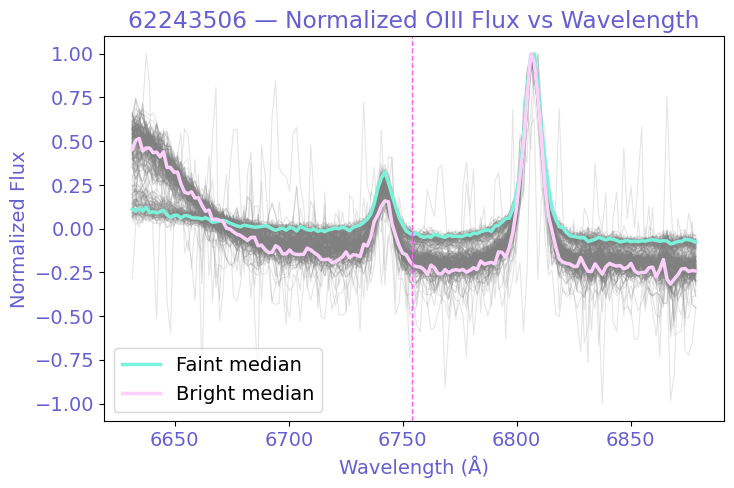

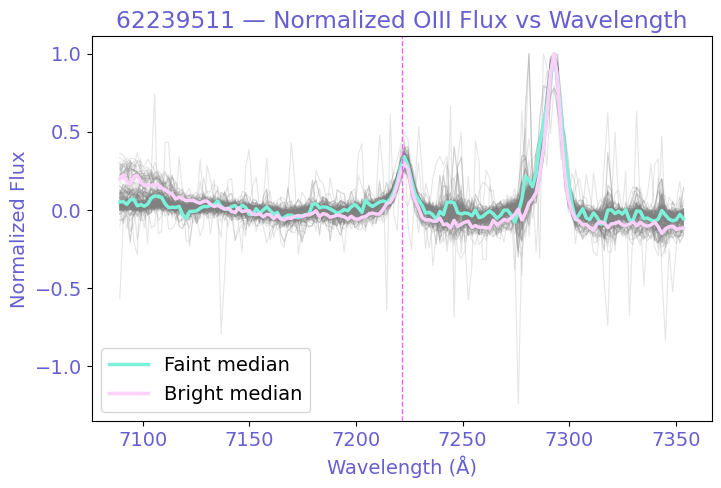

In [191]:
# Parameters
window = 80   # around Halpha
edge   = 20   # continuum estimate from edges

oiii_profiles   = {}
oiii_wavelength = {}
cont_levels   = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    oiii_profiles[target_id] = []
    oiii_wavelength[target_id] = []
    cont_levels[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl = s["wavelength"]
        fl = s["flux"]

        # center index around Hα
        i = np.argmin(np.abs(wl - cntrOiii))

        # skip if window runs off array
        if i - window < 0 or i + window > len(wl):
            continue

        wl_zoom = wl[i-window:i+window]
        fl_zoom = fl[i-window:i+window]

        # continuum estimate from edges
        cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
        cont = np.median(cont_vals)

        # continuum-subtracted line
        fl_line = fl_zoom - cont

        # peak normalization
        peak = np.max(fl_line)
        if peak <= 0 or not np.isfinite(peak):
            continue

        fl_norm = fl_line / peak

        oiii_profiles[target_id].append(fl_norm)
        oiii_wavelength[target_id].append(wl_zoom)
        cont_levels[target_id].append(cont)

    oiii_profiles[target_id] = np.array(oiii_profiles[target_id])
    oiii_wavelength[target_id] = np.array(oiii_wavelength[target_id])
    cont_levels[target_id] = np.array(cont_levels[target_id])

    if len(cont_levels[target_id]) == 0:
        continue

    order = np.argsort(cont_levels[target_id])
    n_select = min(10, len(order))

    faint_idx = order[:n_select]
    bright_idx = order[-n_select:]

    wl_ref = oiii_wavelength[target_id][0]
    bright_med = np.median(oiii_profiles[target_id][bright_idx], axis=0)
    faint_med  = np.median(oiii_profiles[target_id][faint_idx], axis=0)

    plt.figure(figsize=(8,5))

    # all epochs in gray
    for wl_zoom, prof in zip(oiii_wavelength[target_id], oiii_profiles[target_id]):
        plt.plot(wl_zoom, prof, color="gray", alpha=0.2, linewidth=0.8)

    # medians
    plt.plot(wl_ref, faint_med, color="xkcd:tiffany blue", linewidth=2.5, label="Faint median")
    plt.plot(wl_ref, bright_med, color="xkcd:pale mauve", linewidth=2.5, label="Bright median")

    plt.axvline(cntrOiii, color="xkcd:light magenta", linestyle="--", linewidth=1)

    plt.xlabel("Wavelength (Å)",color="xkcd:dark periwinkle")
    plt.ylabel("Normalized Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} — Normalized OIII Flux vs Wavelength",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    
    plt.legend()
    plt.show()

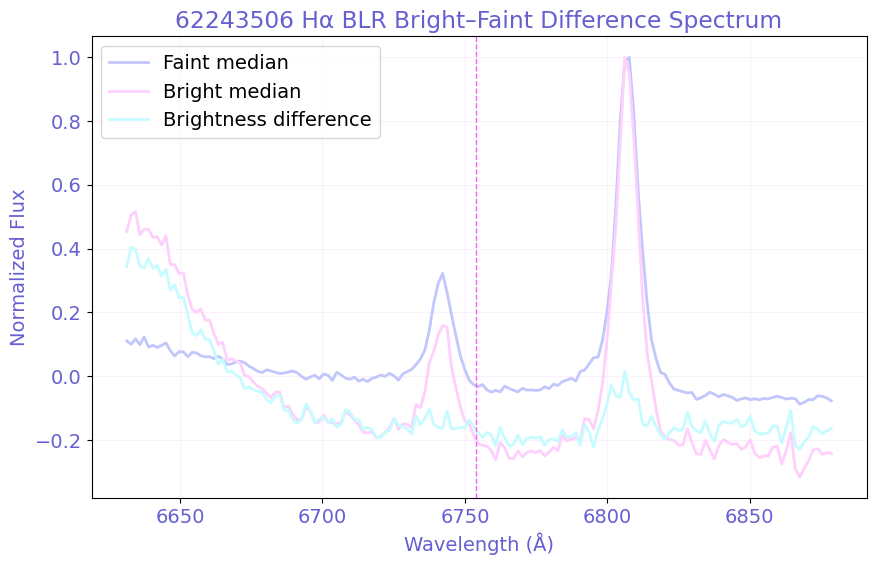

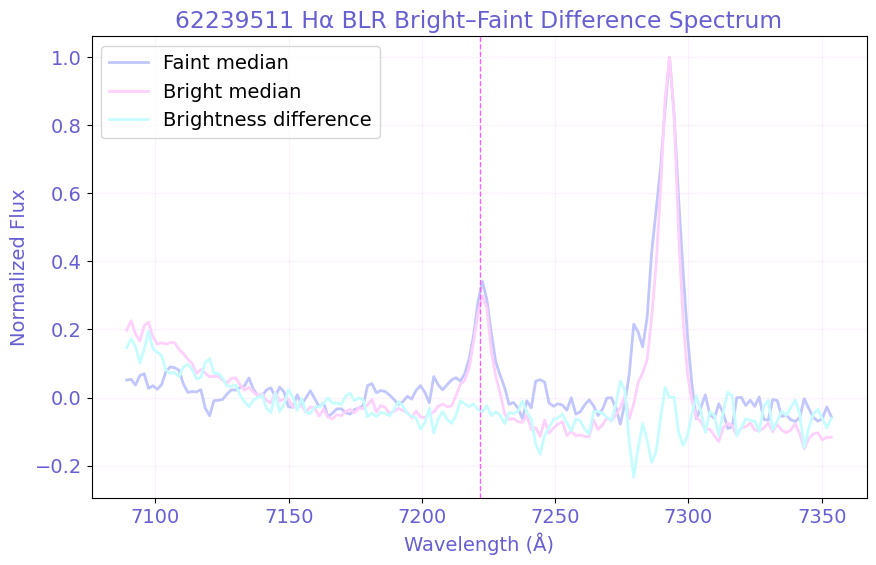

In [192]:
window = 80
edge = 20

iii_profiles = {}
piii_wavelength = {}
cont_levels = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    oiii_profiles[target_id] = []
    oiii_wavelength[target_id] = []
    cont_levels[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl = s["wavelength"]
        fl = s["flux"]

        # center index around Hβ
        i = np.argmin(np.abs(wl - cntrOiii))

        # skip if window runs off array
        if i - window < 0 or i + window > len(wl):
            continue

        wl_zoom = wl[i-window:i+window]
        fl_zoom = fl[i-window:i+window]

        # continuum estimate from edges
        cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
        cont = np.median(cont_vals)

        # continuum-subtracted line
        fl_line = fl_zoom - cont

        # peak normalization
        peak = np.max(fl_line)
        if peak <= 0 or not np.isfinite(peak):
            continue

        fl_norm = fl_line / peak

        oiii_profiles[target_id].append(fl_norm)
        oiii_wavelength[target_id].append(wl_zoom)
        cont_levels[target_id].append(cont)

    oiii_profiles[target_id] = np.array(oiii_profiles[target_id])
    oiii_wavelength[target_id] = np.array(oiii_wavelength[target_id])
    cont_levels[target_id] = np.array(cont_levels[target_id])

    if len(cont_levels[target_id]) == 0:
        continue

    order = np.argsort(cont_levels[target_id])
    n_select = min(10, len(order))

    faint_idx = order[:n_select]
    bright_idx = order[-n_select:]

    wl_ref = oiii_wavelength[target_id][0]
    faint_med = np.median(oiii_profiles[target_id][faint_idx], axis=0)
    bright_med = np.median(oiii_profiles[target_id][bright_idx], axis=0)

    diff = bright_med - faint_med

    plt.figure(figsize=(10,6))
    plt.plot(wl_ref, faint_med, color="xkcd:light periwinkle", linewidth=2, label="Faint median")
    plt.plot(wl_ref, bright_med, color="xkcd:pale mauve", linewidth=2, label="Bright median")
    plt.plot(wl_ref, diff, color="xkcd:light sky blue", linewidth=2, label="Brightness difference")

    plt.axvline(cntrOiii, color="xkcd:light magenta", linestyle="--", linewidth=1)

    plt.xlabel("Wavelength (Å)",color="xkcd:dark periwinkle")
    plt.ylabel("Normalized Flux",color="xkcd:dark periwinkle")
    plt.title(f"{target_id} Hα BLR Bright–Faint Difference Spectrum",color="xkcd:dark periwinkle")
    plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
    plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)
    
    plt.legend()
    plt.show()

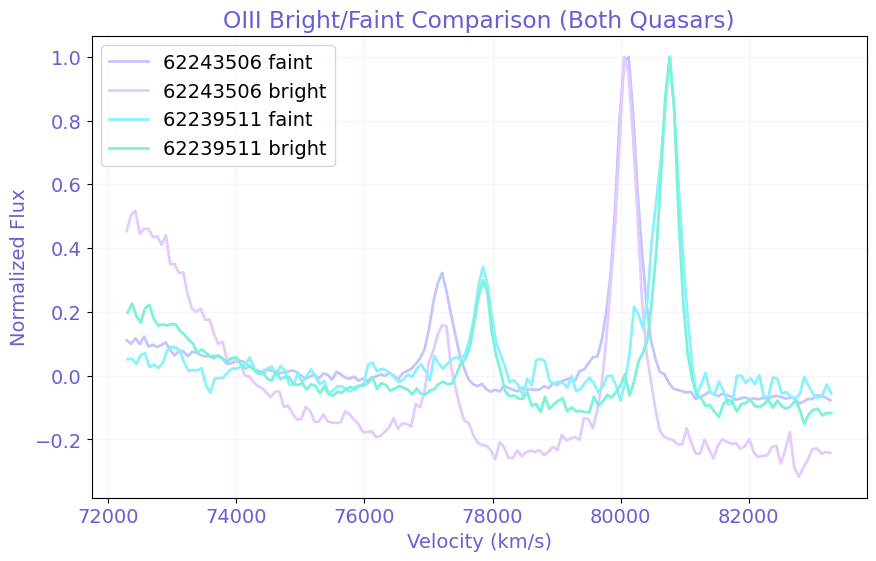

In [193]:
c = 3e5
window = 80
edge = 20
n_select = 10

oiii_profiles = {}
oiii_vel = {}
cont_levels = {}

faint_med_all = {}
bright_med_all = {}
vel_ref_all = {}

for target_id in [62243506, 62239511]:
    cntrHb, cntrHa, cntrOiii = center_map[target_id]

    oiii_profiles[target_id] = []
    oiii_vel[target_id] = []
    cont_levels[target_id] = []

    for s in spectra:
        if s["sdss_id"] != target_id:
            continue

        wl = s["wavelength"]
        fl = s["flux"]

        i = np.argmin(np.abs(wl - cntrOiii))

        if i - window < 0 or i + window > len(wl):
            continue

        wl_zoom = wl[i-window:i+window]
        fl_zoom = fl[i-window:i+window]

        cont_vals = np.append(fl_zoom[:edge], fl_zoom[-edge:])
        cont = np.median(cont_vals)

        fl_line = fl_zoom - cont

        peak = np.max(fl_line)
        if peak <= 0 or not np.isfinite(peak):
            continue

        fl_norm = fl_line / peak
        vel = c * (wl_zoom - cntrHb) / cntrOiii

        oiii_profiles[target_id].append(fl_norm)
        oiii_vel[target_id].append(vel)
        cont_levels[target_id].append(cont)

    oiii_profiles[target_id] = np.array(oiii_profiles[target_id])
    oiii_vel[target_id] = np.array(oiii_vel[target_id])
    cont_levels[target_id] = np.array(cont_levels[target_id])

    if len(cont_levels[target_id]) == 0:
        continue

    order = np.argsort(cont_levels[target_id])
    n_use = min(n_select, len(order))

    faint_idx = order[:n_use]
    bright_idx = order[-n_use:]

    vel_ref_all[target_id] = ha_vel[target_id][0]
    faint_med_all[target_id] = np.median(oiii_profiles[target_id][faint_idx], axis=0)
    bright_med_all[target_id] = np.median(oiii_profiles[target_id][bright_idx], axis=0)

# ---------- PLOT BOTH TOGETHER ----------
plt.figure(figsize=(10,6))

# first quasar
plt.plot(vel_ref_all[62243506], faint_med_all[62243506],
         color="xkcd:light periwinkle", linewidth=2, label="62243506 faint")
plt.plot(vel_ref_all[62243506], bright_med_all[62243506],
         color="xkcd:pale lilac", linewidth=2, label="62243506 bright")

# second quasar
plt.plot(vel_ref_all[62239511], faint_med_all[62239511],
         color="xkcd:robin egg blue", linewidth=2, label="62239511 faint")
plt.plot(vel_ref_all[62239511], bright_med_all[62239511],
         color="xkcd:tiffany blue", linewidth=2, label="62239511 bright")

#plt.axvline(0, color="xkcd:pale mauve", linestyle="--", linewidth=1)

plt.xlabel("Velocity (km/s)",color="xkcd:dark periwinkle")
plt.ylabel("Normalized Flux",color="xkcd:dark periwinkle")
plt.title("OIII Bright/Faint Comparison (Both Quasars)",color="xkcd:dark periwinkle")
plt.tick_params(axis='both', labelcolor="xkcd:dark periwinkle")
plt.grid(True, which='both', color="xkcd:very light purple", alpha =0.3)

plt.legend()
plt.show()